In [1]:
import pandas as pd
import geopandas as gpd
from pathlib import Path

# Works when the notebook is run from the project root or /notebooks.
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_INTERIM = PROJECT_ROOT / "data" / "interim"
BOUNDARIES_DIR = PROJECT_ROOT / "data" / "boundaries"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"

BOUNDARY_DIR = BOUNDARIES_DIR / "cb_2025_us_county_500k"
COUNTY_SHP = BOUNDARY_DIR / "cb_2025_us_county_500k.shp"

print("Project root:", PROJECT_ROOT)
print("2025 boundary file:", COUNTY_SHP)

assert COUNTY_SHP.exists(), f"2025 county shapefile not found: {COUNTY_SHP}"


Project root: C:\thesis-modeltraining\county-obesity-prediction
2025 boundary file: C:\thesis-modeltraining\county-obesity-prediction\data\boundaries\cb_2025_us_county_500k\cb_2025_us_county_500k.shp


In [2]:
counties_gdf = gpd.read_file(COUNTY_SHP)

counties_gdf["GEOID"] = counties_gdf["GEOID"].astype("string").str.zfill(5)

required_boundary_columns = {
    "GEOID", "STATE_NAME", "STUSPS", "NAMELSAD", "geometry"
}
missing_columns = required_boundary_columns - set(counties_gdf.columns)
assert not missing_columns, f"Missing expected boundary columns: {sorted(missing_columns)}"
assert counties_gdf["GEOID"].is_unique, "Duplicate county GEOIDs found in 2025 boundaries."
assert counties_gdf.geometry.notna().all(), "Missing county geometries found."

print("Boundary rows:", len(counties_gdf))
print("Unique GEOIDs:", counties_gdf["GEOID"].nunique())
print("CRS:", counties_gdf.crs)
print("Columns:", counties_gdf.columns.tolist())

display(counties_gdf[["GEOID", "STATE_NAME", "STUSPS", "NAMELSAD"]].head())


Boundary rows: 3235
Unique GEOIDs: 3235
CRS: EPSG:4269
Columns: ['STATEFP', 'COUNTYFP', 'COUNTYNS', 'GEOIDFQ', 'GEOID', 'NAME', 'NAMELSAD', 'STUSPS', 'STATE_NAME', 'LSAD', 'ALAND', 'AWATER', 'geometry']


,GEOID,STATE_NAME,STUSPS,NAMELSAD
0,06085,California,CA,Santa Clara County
1,06059,California,CA,Orange County
2,17043,Illinois,IL,DuPage County
3,04027,Arizona,AZ,Yuma County
4,01003,Alabama,AL,Baldwin County


In [4]:
final_stacking_predictions = pd.read_csv(
    OUTPUTS_DIR / "stacking_v2" / "stacking_v2_outer_predictions.csv",
    dtype={"FIPS": "string"}
)

final_modeling_data = pd.read_csv(
    DATA_INTERIM / "modeling_data.csv",
    dtype={"FIPS": "string"}
)

final_stacking_predictions["FIPS"] = (
    final_stacking_predictions["FIPS"].str.zfill(5)
)
final_modeling_data["FIPS"] = final_modeling_data["FIPS"].str.zfill(5)

assert len(final_stacking_predictions) == 3135
assert final_stacking_predictions["FIPS"].nunique() == 3135
assert not final_stacking_predictions["FIPS"].duplicated().any()

final_county_results = final_stacking_predictions.merge(
    final_modeling_data[["FIPS", "State", "County"]],
    on="FIPS",
    how="left",
    validate="one_to_one"
)

final_county_results["Prediction_Difference"] = (
    final_county_results["Stacking_Prediction"]
    - final_county_results["Actual"]
)

assert final_county_results[["State", "County"]].notna().all().all()

print("Prediction rows:", len(final_stacking_predictions))
print("Unique prediction FIPS:", final_stacking_predictions["FIPS"].nunique())
print("Prediction difference range:",
    final_county_results["Prediction_Difference"].min(), "to",
    final_county_results["Prediction_Difference"].max())

display(final_county_results.head())


Prediction rows: 3135
Unique prediction FIPS: 3135
Prediction difference range: -9.46754883415516 to 11.309353461470284


,FIPS,Actual,LR_Prediction,RF_Prediction,XGB_Prediction,Stacking_Prediction,Outer_Fold,State,County,Prediction_Difference
0,01001,38.4,38.542913,38.567,38.655193,38.667624,1,AL,Autauga,0.267624
1,01029,39.4,40.021657,39.554,40.101280,40.186954,1,AL,Cleburne,0.786954
2,01035,44.7,44.435121,44.765,44.675095,44.946170,1,AL,Conecuh,0.246170
3,01045,44.3,40.705231,39.669,39.523600,39.783823,1,AL,Dale,-4.516177
4,01051,36.4,38.834156,37.342,38.224610,38.334515,1,AL,Elmore,1.934515


In [5]:
boundary_fips = set(counties_gdf["GEOID"].astype(str))
result_fips = set(final_county_results["FIPS"].astype(str))

matched_fips = result_fips & boundary_fips
missing_in_boundaries = result_fips - boundary_fips
boundaries_without_results = boundary_fips - result_fips

print("Prediction FIPS:", len(result_fips))
print("2025 boundary GEOIDs:", len(boundary_fips))
print("Matched prediction FIPS:", len(matched_fips))
print("Prediction FIPS missing in 2025 boundaries:", len(missing_in_boundaries))
print("2025 boundary GEOIDs without prediction results:", len(boundaries_without_results))

if missing_in_boundaries:
    print("\nMissing prediction FIPS:", sorted(missing_in_boundaries))

assert len(matched_fips) == 3135, (
    f"Expected all 3,135 prediction FIPS to match, but only {len(matched_fips)} matched."
)
assert not missing_in_boundaries, (
    f"Prediction FIPS missing from 2025 boundaries: {sorted(missing_in_boundaries)}"
)


Prediction FIPS: 3135
2025 boundary GEOIDs: 3235
Matched prediction FIPS: 3135
Prediction FIPS missing in 2025 boundaries: 0
2025 boundary GEOIDs without prediction results: 100


In [6]:
final_map_gdf = counties_gdf.merge(
    final_county_results,
    left_on="GEOID",
    right_on="FIPS",
    how="inner",
    validate="one_to_one"
)

final_map_ready_gdf = final_map_gdf[[
    "FIPS",
    "STATE_NAME",
    "STUSPS",
    "NAMELSAD",
    "Actual",
    "Stacking_Prediction",
    "Prediction_Difference",
    "Outer_Fold",
    "geometry"
]].copy().rename(columns={
    "STATE_NAME": "State_Name",
    "STUSPS": "State_Abbreviation",
    "NAMELSAD": "County_Name",
    "Actual": "CDC_Obesity_AdjPrev",
    "Stacking_Prediction": "Predicted_Obesity_AdjPrev"
})

assert len(final_map_ready_gdf) == 3135
assert final_map_ready_gdf["FIPS"].nunique() == 3135
assert not final_map_ready_gdf["FIPS"].duplicated().any()
assert final_map_ready_gdf.geometry.notna().all()
assert not final_map_ready_gdf[[
    "CDC_Obesity_AdjPrev",
    "Predicted_Obesity_AdjPrev",
    "Prediction_Difference"
]].isna().any().any()

print("Final map rows:", len(final_map_ready_gdf))
print("Unique FIPS:", final_map_ready_gdf["FIPS"].nunique())
print("Missing geometry:", final_map_ready_gdf.geometry.isna().sum())
print("CRS:", final_map_ready_gdf.crs)

display(final_map_ready_gdf.head())


Final map rows: 3135
Unique FIPS: 3135
Missing geometry: 0
CRS: EPSG:4269


,FIPS,State_Name,State_Abbreviation,County_Name,CDC_Obesity_AdjPrev,Predicted_Obesity_AdjPrev,Prediction_Difference,Outer_Fold,geometry
0,06085,California,CA,Santa Clara County,22.0,21.721423,-0.278577,2,"POLYGON ((-122.20265 37.36305, -122.20132 37.3..."
1,06059,California,CA,Orange County,25.7,23.764972,-1.935028,5,"POLYGON ((-118.11464 33.74461, -118.11406 33.7..."
2,17043,Illinois,IL,DuPage County,29.4,28.199311,-1.200689,4,"POLYGON ((-88.26288 41.98244, -88.26288 41.986..."
3,04027,Arizona,AZ,Yuma County,42.3,38.092632,-4.207368,1,"POLYGON ((-114.81629 32.50804, -114.81432 32.5..."
4,01003,Alabama,AL,Baldwin County,36.8,36.248156,-0.551844,5,"POLYGON ((-88.02858 30.22676, -88.02399 30.230..."


In [7]:
FINAL_MAP_OUTPUT_DIR = OUTPUTS_DIR / "map_final"
FINAL_MAP_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

final_map_ready_gdf.drop(columns="geometry").to_csv(
    FINAL_MAP_OUTPUT_DIR / "final_county_map_data.csv",
    index=False
)

final_map_ready_gdf.to_file(
    FINAL_MAP_OUTPUT_DIR / "final_county_map_data.geojson",
    driver="GeoJSON"
)

verification_df = pd.DataFrame([{
    "boundary_vintage": 2025,
    "boundary_file": COUNTY_SHP.name,
    "prediction_rows": len(final_stacking_predictions),
    "unique_prediction_FIPS": final_stacking_predictions["FIPS"].nunique(),
    "matched_boundary_FIPS": len(matched_fips),
    "prediction_FIPS_missing_in_boundaries": len(missing_in_boundaries),
    "boundaries_without_prediction_results": len(boundaries_without_results),
    "map_rows": len(final_map_ready_gdf),
    "missing_geometries": int(final_map_ready_gdf.geometry.isna().sum()),
    "missing_predictions": int(final_map_ready_gdf["Predicted_Obesity_AdjPrev"].isna().sum()),
    "prediction_difference_min": final_map_ready_gdf["Prediction_Difference"].min(),
    "prediction_difference_max": final_map_ready_gdf["Prediction_Difference"].max(),
    "crs": str(final_map_ready_gdf.crs)
}])

verification_df.to_csv(
    FINAL_MAP_OUTPUT_DIR / "final_mapping_verification.csv",
    index=False
)

pd.DataFrame({"FIPS": sorted(missing_in_boundaries)}).to_csv(
    FINAL_MAP_OUTPUT_DIR / "prediction_fips_missing_in_boundaries.csv",
    index=False
)

print("Saved final 2025-boundary mapping outputs to:", FINAL_MAP_OUTPUT_DIR)
display(verification_df)


Saved final 2025-boundary mapping outputs to: C:\thesis-modeltraining\county-obesity-prediction\outputs\map_final


,boundary_vintage,boundary_file,prediction_rows,unique_prediction_FIPS,matched_boundary_FIPS,prediction_FIPS_missing_in_boundaries,boundaries_without_prediction_results,map_rows,missing_geometries,missing_predictions,prediction_difference_min,prediction_difference_max,crs
0,2025,cb_2025_us_county_500k.shp,3135,3135,3135,0,100,3135,0,0,-9.467549,11.309353,EPSG:4269


In [8]:
saved_map_geojson = gpd.read_file(
    FINAL_MAP_OUTPUT_DIR / "final_county_map_data.geojson"
)

assert len(saved_map_geojson) == 3135
assert saved_map_geojson["FIPS"].astype(str).nunique() == 3135
assert saved_map_geojson.geometry.notna().all()

print("Reloaded rows:", len(saved_map_geojson))
print("Unique FIPS:", saved_map_geojson["FIPS"].astype(str).nunique())
print("Missing geometry:", saved_map_geojson.geometry.isna().sum())
print("CRS:", saved_map_geojson.crs)
print("Prediction difference range:",
    saved_map_geojson["Prediction_Difference"].min(), "to",
    saved_map_geojson["Prediction_Difference"].max())


Reloaded rows: 3135
Unique FIPS: 3135
Missing geometry: 0
CRS: EPSG:4269
Prediction difference range: -9.46754883415516 to 11.309353461470284


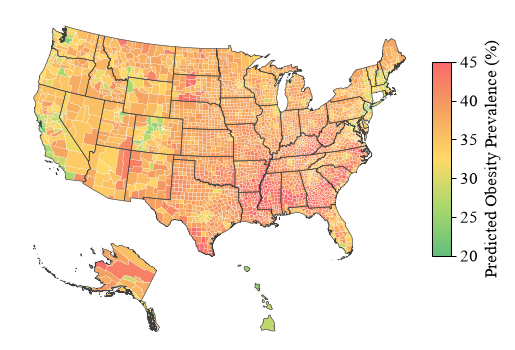

FIG. 2 - 2025 CENSUS BOUNDARIES CREATED
Boundary year: 2025
Figure width: 3.5 inches
Figure height: 2.35 inches
Typography: Times New Roman, 8 pt
PNG resolution: 400 DPI

PNG:
C:\thesis-modeltraining\county-obesity-prediction\outputs\conference_figures\county_prediction_map_v2.png

PDF:
C:\thesis-modeltraining\county-obesity-prediction\outputs\conference_figures\county_prediction_map_v2.pdf


In [ ]:
# ============================================================
# CONFERENCE FIG. 2 - FINAL PUBLICATION VERSION
# Predicted Adult Obesity Prevalence by U.S. County
# 2025 U.S. Census Bureau County Boundaries
# Final V2 Stacking Ensemble
#
# IEEE / ISCMI single-column figure
# Final width: approximately 3.5 inches
# ============================================================

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.colors import LinearSegmentedColormap
from pathlib import Path


# ------------------------------------------------------------
# 1. PUBLICATION TYPOGRAPHY
# ------------------------------------------------------------

plt.rcParams.update({
    "font.family": "serif",
    "font.serif": [
        "Times New Roman",
        "Times",
        "DejaVu Serif"
    ],
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8,

    # Preserve editable/vector text in PDF
    "pdf.fonttype": 42,
    "ps.fonttype": 42
})


# ------------------------------------------------------------
# 2. OUTPUT DIRECTORY
# ------------------------------------------------------------

FIGURE_DIR = (
    PROJECT_ROOT
    / "outputs"
    / "conference_figures"
)

FIGURE_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ------------------------------------------------------------
# 3. USE VERIFIED 2025 MAP DATA
# ------------------------------------------------------------

# This must be the GeoDataFrame created from:
# 2025 Census county boundaries + held-out predictions
map_gdf = final_map_ready_gdf.copy()

excluded_main = [
    "Alaska",
    "Hawaii",
    "Puerto Rico"
]

contiguous = map_gdf[
    ~map_gdf["State_Name"].isin(excluded_main)
].copy()

alaska = map_gdf[
    map_gdf["State_Name"] == "Alaska"
].copy()

hawaii = map_gdf[
    map_gdf["State_Name"] == "Hawaii"
].copy()


# ------------------------------------------------------------
# 4. REPROJECT FOR U.S. MAPPING
# ------------------------------------------------------------

# NAD83 / Conus Albers
target_crs = "EPSG:5070"

contiguous = contiguous.to_crs(target_crs)
alaska = alaska.to_crs(target_crs)
hawaii = hawaii.to_crs(target_crs)


# ------------------------------------------------------------
# 5. CREATE STATE BOUNDARIES
# ------------------------------------------------------------

contiguous_states = contiguous.dissolve(
    by="State_Name"
)

alaska_state = alaska.dissolve(
    by="State_Name"
)


# ------------------------------------------------------------
# 6. PREPARE HAWAII FOR INSET DISPLAY
# ------------------------------------------------------------

# Hawaii counties contain multipart geometries.
# Explode them into individual island polygons.
hawaii_display = hawaii.explode(
    index_parts=False
).copy()

# Calculate polygon area for display selection.
hawaii_display["_area"] = (
    hawaii_display.geometry.area
)

# Retain the eight largest island polygons.
# This prevents tiny remote polygons from forcing
# the Hawaii inset to zoom too far out.
hawaii_display = (
    hawaii_display
    .sort_values(
        "_area",
        ascending=False
    )
    .head(8)
    .copy()
)


# ------------------------------------------------------------
# 7. PUBLICATION COLOR SCALE
# ------------------------------------------------------------

colors = [
    "#63BE7B",   # lower predicted prevalence
    "#A9D86E",
    "#FFD966",
    "#F4A261",
    "#F8696B"    # higher predicted prevalence
]

obesity_cmap = LinearSegmentedColormap.from_list(
    "obesity_scale",
    colors
)

# Fixed scale used in the original publication figure
vmin = 20
vmax = 45

norm = mpl.colors.Normalize(
    vmin=vmin,
    vmax=vmax
)


# ------------------------------------------------------------
# 8. CREATE SINGLE-COLUMN FIGURE
# ------------------------------------------------------------

# Same dimensions as original 2024 publication figure
fig = plt.figure(
    figsize=(3.5, 2.35),
    dpi=150,
    facecolor="white"
)


# ------------------------------------------------------------
# 9. DEFINE MAP AREAS
# ------------------------------------------------------------

# Main contiguous United States
ax_main = fig.add_axes([
    0.015,   # left
    0.18,    # bottom
    0.78,    # width
    0.78     # height
])

# Alaska inset
ax_ak = fig.add_axes([
    0.045,   # left
    0.025,   # bottom
    0.25,    # width
    0.27     # height
])

# Hawaii inset
ax_hi = fig.add_axes([
    0.34,    # left
    0.025,   # bottom
    0.27,    # width
    0.21     # height
])

# Continuous colorbar
cax = fig.add_axes([
    0.81,    # left
    0.25,    # bottom
    0.035,   # width
    0.55     # height
])


# ------------------------------------------------------------
# 10. PLOT CONTIGUOUS UNITED STATES
# ------------------------------------------------------------

contiguous.plot(
    column="Predicted_Obesity_AdjPrev",
    cmap=obesity_cmap,
    norm=norm,

    # Original thin county boundaries
    linewidth=0.10,
    edgecolor="white",

    ax=ax_main
)

# Original state-boundary styling
contiguous_states.boundary.plot(
    ax=ax_main,
    color="#3F3F3F",
    linewidth=0.6
)

ax_main.set_aspect("equal")
ax_main.set_axis_off()


# ------------------------------------------------------------
# 11. PLOT ALASKA INSET
# ------------------------------------------------------------

alaska.plot(
    column="Predicted_Obesity_AdjPrev",
    cmap=obesity_cmap,
    norm=norm,

    # Original thin county boundaries
    linewidth=0.10,
    edgecolor="white",

    ax=ax_ak
)

alaska_state.boundary.plot(
    ax=ax_ak,
    color="#3F3F3F",
    linewidth=0.6
)

# Tight framing around Alaska
ak_minx, ak_miny, ak_maxx, ak_maxy = (
    alaska.total_bounds
)

ak_xpad = (
    ak_maxx - ak_minx
) * 0.02

ak_ypad = (
    ak_maxy - ak_miny
) * 0.02

ax_ak.set_xlim(
    ak_minx - ak_xpad,
    ak_maxx + ak_xpad
)

ax_ak.set_ylim(
    ak_miny - ak_ypad,
    ak_maxy + ak_ypad
)

ax_ak.set_aspect("equal")
ax_ak.set_axis_off()


# ------------------------------------------------------------
# 12. PLOT HAWAII INSET
# ------------------------------------------------------------

hawaii_display.plot(
    column="Predicted_Obesity_AdjPrev",
    cmap=obesity_cmap,
    norm=norm,

    # Original thin island/county boundaries
    linewidth=0.10,
    edgecolor="white",

    ax=ax_hi
)

hawaii_display.boundary.plot(
    ax=ax_hi,
    color="#3F3F3F",
    linewidth=0.6
)

# Tight framing around principal Hawaiian islands
hi_minx, hi_miny, hi_maxx, hi_maxy = (
    hawaii_display.total_bounds
)

hi_xpad = (
    hi_maxx - hi_minx
) * 0.03

hi_ypad = (
    hi_maxy - hi_miny
) * 0.06

ax_hi.set_xlim(
    hi_minx - hi_xpad,
    hi_maxx + hi_xpad
)

ax_hi.set_ylim(
    hi_miny - hi_ypad,
    hi_maxy + hi_ypad
)

ax_hi.set_aspect("equal")
ax_hi.set_axis_off()


# ------------------------------------------------------------
# 13. CONTINUOUS COLORBAR
# ------------------------------------------------------------

sm = mpl.cm.ScalarMappable(
    cmap=obesity_cmap,
    norm=norm
)

sm.set_array([])

colorbar = fig.colorbar(
    sm,
    cax=cax
)

colorbar.set_ticks([
    20,
    25,
    30,
    35,
    40,
    45
])

colorbar.set_label(
    "Predicted Obesity Prevalence (%)",
    fontsize=8,
    labelpad=3
)

colorbar.ax.tick_params(
    axis="y",
    labelsize=8,
    length=2.5,
    width=0.5,
    pad=2
)

colorbar.outline.set_linewidth(
    0.5
)

# Explicitly ensure Times-style font is applied
for tick_label in colorbar.ax.get_yticklabels():
    tick_label.set_fontfamily(
        "Times New Roman"
    )
    tick_label.set_fontsize(8)

colorbar.ax.yaxis.label.set_fontfamily(
    "Times New Roman"
)

colorbar.ax.yaxis.label.set_fontsize(8)


# ------------------------------------------------------------
# 14. OUTPUT FILE PATHS
# ------------------------------------------------------------

png_path = (
    FIGURE_DIR
    / "county_prediction_map_v2.png"
)

pdf_path = (
    FIGURE_DIR
    / "county_prediction_map_v2.pdf"
)


# ------------------------------------------------------------
# 15. SAVE HIGH-RESOLUTION PNG
# ------------------------------------------------------------

fig.savefig(
    png_path,
    dpi=400,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white"
)


# ------------------------------------------------------------
# 16. SAVE VECTOR PDF
# ------------------------------------------------------------

fig.savefig(
    pdf_path,
    bbox_inches="tight",
    pad_inches=0.02,
    facecolor="white"
)


# ------------------------------------------------------------
# 17. DISPLAY FIGURE
# ------------------------------------------------------------

plt.show()


# ------------------------------------------------------------
# 18. CONFIRM OUTPUT
# ------------------------------------------------------------

print("=" * 60)
print("FIG. 2 - 2025 CENSUS BOUNDARIES CREATED")
print("=" * 60)

print("Boundary year: 2025")
print("Figure width: 3.5 inches")
print("Figure height: 2.35 inches")
print("Typography: Times New Roman, 8 pt")
print("PNG resolution: 400 DPI")

print("\nPNG:")
print(png_path)

print("\nPDF:")
print(pdf_path)